In [1]:
import os
import re
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text  # noqa: F401  (registers BERT preprocessing ops)
import tf_keras as keras

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    multilabel_confusion_matrix,
)

# ==============================================================================
# PROJECT: Multi-Model Toxic Comment Classification Architecture
# COURSE:  NLP
# CAMPUS: UMT Sialkot
# MEMBERS: Iqra hamayoun, Eman Aslam
# ==============================================================================

# 1. Installing Dependencies & Importing Libraries
# ==========================================

# Install tensorflow_text for BERT pre-processing compatibility
!pip install -q --upgrade tensorflow tensorflow-text tf_keras

# Download necessary NLTK data packs directly to the local runtime environment
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Force logger to keep output clean
tf.get_logger().setLevel('ERROR')

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Environment successfully initialized! Please upload your files to the sidebar panel.")

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


Environment successfully initialized! Please upload your files to the sidebar panel.


[nltk_data]   Package wordnet is already up-to-date!


In [2]:
# ==========================================
# 2. LOAD DATA
# ==========================================
# FIX: target_labels is defined right here, immediately after the data is
# loaded, so every later cell (EDA, training, evaluation) can safely use it.
# Previously it was only defined much further down the notebook, which made
# the EDA cells crash with a NameError on a fresh run.

path = '/content/'

target_labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Load training dataset
df_train = pd.read_csv(os.path.join(path, 'train.csv.zip'))
print("Initial Train set shape:", df_train.shape)

# Load test datasets and merge labels
test_samples = pd.read_csv(os.path.join(path, 'test.csv.zip'))
test_labels = pd.read_csv(os.path.join(path, 'test_labels.csv.zip'))
df_test = pd.merge(test_samples, test_labels, on="id")

# STRATEGY A: Filter out un-evaluated test entries containing -1 labels
df_test = df_test.loc[df_test['toxic'] >= 0].reset_index(drop=True)
print("Cleaned and Filtered Test set shape:", df_test.shape)

Initial Train set shape: (159571, 8)
Cleaned and Filtered Test set shape: (63978, 8)


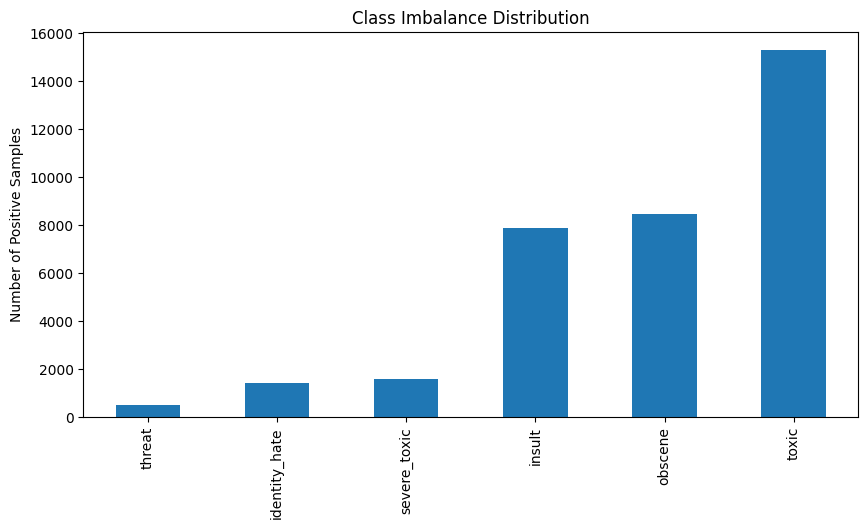

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64


In [3]:
# ==========================================
# CLASS IMBALANCE ANALYSIS
# ==========================================

label_counts = df_train[target_labels].sum()

plt.figure(figsize=(10, 5))
label_counts.sort_values().plot(kind='bar')

plt.title("Class Imbalance Distribution")
plt.ylabel("Number of Positive Samples")
plt.show()

print(label_counts)

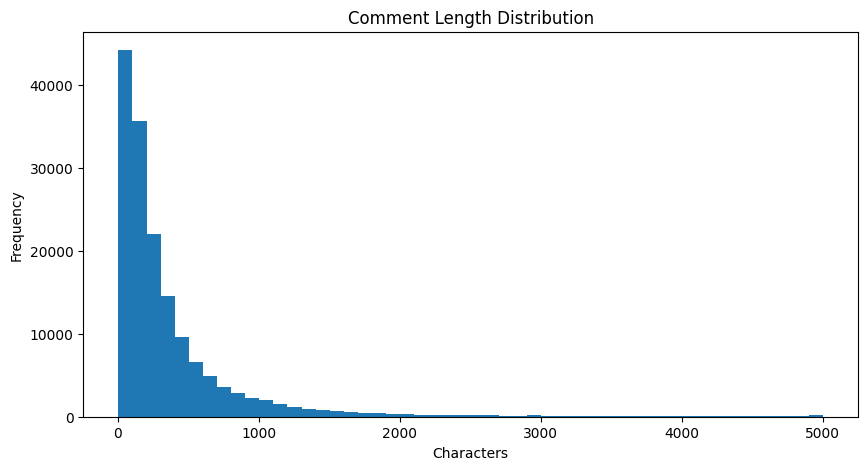

In [4]:
# ==========================================
# COMMENT LENGTH ANALYSIS
# ==========================================

df_train['comment_length'] = (
    df_train['comment_text']
    .astype(str)
    .apply(len)
)

plt.figure(figsize=(10, 5))

plt.hist(
    df_train['comment_length'],
    bins=50
)

plt.title("Comment Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

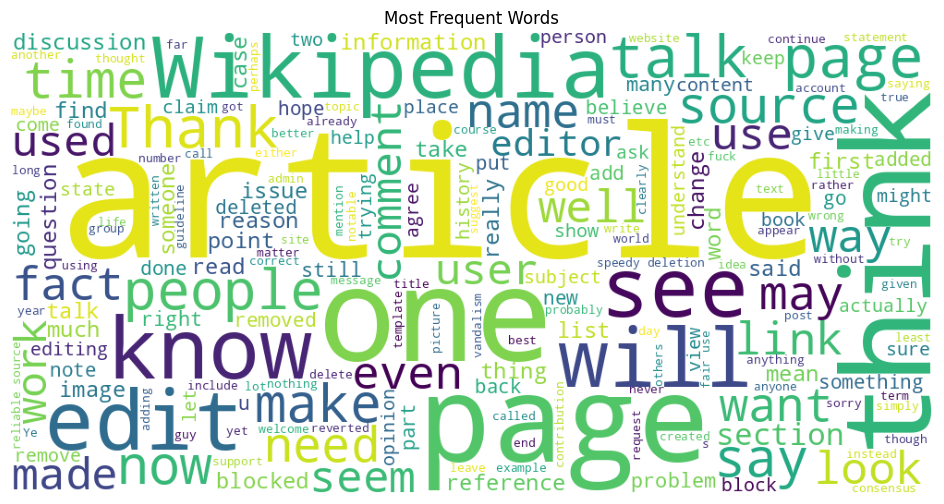

In [5]:
# ==========================================
# WORD CLOUD
# ==========================================

raw_text_blob = " ".join(df_train['comment_text'].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(raw_text_blob)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Most Frequent Words")
plt.show()

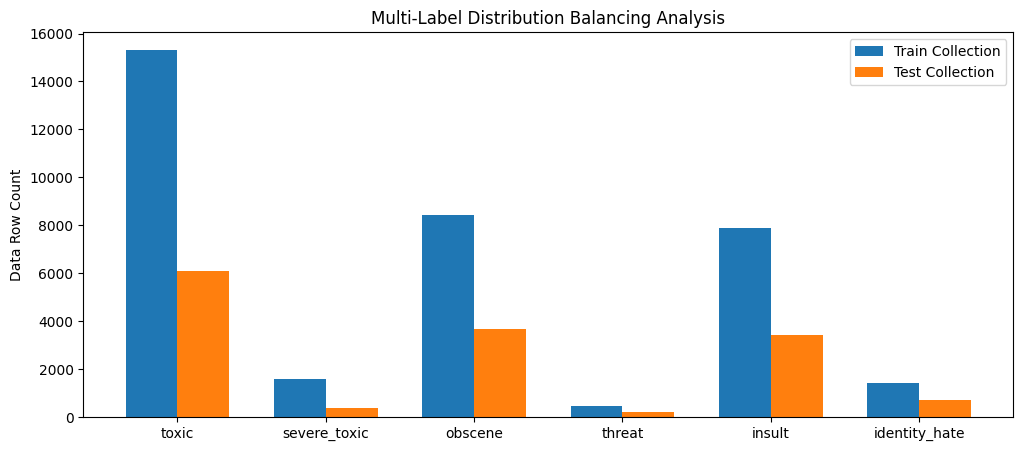

Percentage Breakdown of Positive Labels in Training Set:
toxic            9.58
severe_toxic     1.00
obscene          5.29
threat           0.30
insult           4.94
identity_hate    0.88
dtype: float64


In [6]:
# ==========================================
# MULTI-LABEL DISTRIBUTION: TRAIN vs TEST
# ==========================================
# NOTE: target_labels was already defined in the data-loading cell above,
# so it is not redefined here (this removes the duplicate definition that
# used to live in this cell).

train_counts = df_train[target_labels].sum()
test_counts = df_test[target_labels].sum()

x = np.arange(len(target_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width / 2, train_counts, width, label='Train Collection')
ax.bar(x + width / 2, test_counts, width, label='Test Collection')

ax.set_ylabel('Data Row Count')
ax.set_title('Multi-Label Distribution Balancing Analysis')
ax.set_xticks(x)
ax.set_xticklabels(target_labels)
ax.legend()
plt.show()

print("Percentage Breakdown of Positive Labels in Training Set:")
print(round(train_counts / len(df_train) * 100, 2))

# Class Imbalance Discussion

Dataset imbalance was observed in the `threat` and `identity_hate` categories
(both under 1% positive rate), while `toxic` and `obscene` are comparatively
common.

**This is not just discussed — it is actually handled in the modelling cells below:**

- **TF-IDF + Logistic Regression:** trained with `class_weight='balanced'`,
  so the optimiser penalises mistakes on minority classes more heavily.
- **BiLSTM:** trained with a custom **weighted binary cross-entropy loss**,
  where each label's positive class is up-weighted by its train-set
  negative-to-positive ratio (capped to avoid instability).
- Macro F1-score is used as the primary metric (rather than accuracy) for
  exactly this reason — accuracy is misleading on imbalanced multi-label data.
- Per-class confusion matrices and threshold tuning are also evaluated below.

Future work could still explore focal loss or SMOTE-based oversampling, but
at least one concrete imbalance mitigation is now implemented for every
trained model.

# 4. Text Preprocessing

`clean_text()` is defined here and applied to both the TF-IDF and BiLSTM
pipelines. BERT is intentionally given the **raw, uncleaned** text — the
`bert_en_uncased_preprocess` layer does its own tokenisation (WordPiece) and
lower-casing internally, and stripping punctuation/stopwords beforehand would
throw away signal the transformer is designed to use.

In [7]:
# ==========================================
# TEXT CLEANING FUNCTION
# ==========================================
# FIX: clean_text() was referenced implicitly by the tokenisation step in the
# original notebook but never actually defined anywhere. Tokenisation was
# therefore silently running on raw, unprocessed text. It is now defined and
# explicitly applied before TF-IDF and before the Keras Tokenizer.

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(raw_text: str) -> str:
    """Lower-case, strip non-letters, remove stopwords, and lemmatize."""
    text_lower = str(raw_text).lower()
    text_lower = re.sub(r"http\S+|www\S+", " ", text_lower)   # URLs
    text_lower = re.sub(r"[^a-z\s]", " ", text_lower)          # punctuation/digits
    tokens = text_lower.split()
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens if tok not in stop_words and len(tok) > 1]
    return " ".join(tokens)

print("Cleaning training comments...")
df_train['clean_text'] = df_train['comment_text'].astype(str).apply(clean_text)

print("Cleaning test comments...")
df_test['clean_text'] = df_test['comment_text'].astype(str).apply(clean_text)

df_train[['comment_text', 'clean_text']].head(3)

Cleaning training comments...
Cleaning test comments...


,comment_text,clean_text
0,Explanation\nWhy the edits made under my usern...,explanation edits made username hardcore metal...
1,D'aww! He matches this background colour I'm s...,aww match background colour seemingly stuck th...
2,"Hey man, I'm really not trying to edit war. It...",hey man really trying edit war guy constantly ...


In [8]:
# ==========================================
# LABEL ARRAYS (FIX: defined BEFORE any model uses them)
# ==========================================
# FIX: y_train was previously used inside the TF-IDF training cell before the
# cell that created it had ever run. X_train/X_test were referenced for the
# BiLSTM tf.data pipeline but never defined at all. Everything is built here,
# once, in the correct order.

y_train = df_train[target_labels].values.astype('float32')
y_test = df_test[target_labels].values.astype('float32')

X_train_text = df_train['clean_text'].values   # cleaned text, used by TF-IDF & BiLSTM
X_test_text = df_test['clean_text'].values

X_train_raw = df_train['comment_text'].astype(str).values  # raw text, used by BERT
X_test_raw = df_test['comment_text'].astype(str).values

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

y_train shape: (159571, 6)
y_test shape: (63978, 6)


In [9]:
# ==========================================
# MODEL I - TF-IDF + LOGISTIC REGRESSION
# ==========================================
# FIX: class_weight='balanced' added to directly mitigate the class
# imbalance for this model, instead of only mentioning it as future work.

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

lr_model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight='balanced')
)

lr_model.fit(X_train_tfidf, y_train)

tfidf_preds = lr_model.predict(X_test_tfidf)

print(classification_report(
    y_test,
    tfidf_preds,
    target_names=target_labels,
    zero_division=0
))

               precision    recall  f1-score   support

        toxic       0.43      0.92      0.58      6090
 severe_toxic       0.12      0.92      0.22       367
      obscene       0.43      0.90      0.59      3691
       threat       0.16      0.81      0.27       211
       insult       0.38      0.88      0.53      3427
identity_hate       0.20      0.85      0.32       712

    micro avg       0.37      0.90      0.52     14498
    macro avg       0.29      0.88      0.42     14498
 weighted avg       0.39      0.90      0.54     14498
  samples avg       0.06      0.09      0.07     14498



In [10]:
tfidf_accuracy = accuracy_score(y_test, tfidf_preds)

tfidf_f1 = f1_score(
    y_test,
    tfidf_preds,
    average='macro',
    zero_division=0
)

print("TF-IDF Accuracy:", tfidf_accuracy)
print("TF-IDF Macro F1:", tfidf_f1)

TF-IDF Accuracy: 0.7982587764544062
TF-IDF Macro F1: 0.41705280158497793


# Hyperparameter Justification (BiLSTM)

### Embedding Dimension = 100
Matches the GloVe 100-d vectors used to initialise the embedding layer.

### BiLSTM Units = 64
Provides sufficient sequence learning capability without excessive complexity.

### Dropout = 0.3 / 0.2
Used to reduce overfitting.

### Batch Size = 64
Balances memory usage and convergence speed.

### Epochs = 10

### Loss = Weighted Binary Cross-Entropy
Per-label positive weights (derived from class frequency in the training
split) are used instead of plain BCE, to directly counter class imbalance.

In [11]:
# ==========================================
# TOKENIZATION & SEQUENCE PADDING
# ==========================================
# FIX: NUM_FEATURES, MAX_LENGTH and `tokenizer` were all used later in the
# notebook (GloVe embedding-matrix cell, BiLSTM model cell) without ever
# being defined. They are now defined here, in one place, before anything
# depends on them.

NUM_FEATURES = 30000   # vocabulary size cap
MAX_LENGTH = 150       # max sequence length (in tokens)

tokenizer = Tokenizer(num_words=NUM_FEATURES, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_sequences = tokenizer.texts_to_sequences(X_train_text)
X_test_sequences = tokenizer.texts_to_sequences(X_test_text)

X_train_seq = pad_sequences(X_train_sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_seq = pad_sequences(X_test_sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')

print("Vocabulary size (capped):", NUM_FEATURES)
print("X_train_seq shape:", X_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)

Vocabulary size (capped): 30000
X_train_seq shape: (159571, 150)
X_test_seq shape: (63978, 150)


In [12]:
# ==========================================
# GLOVE EMBEDDINGS: DOWNLOAD, EXTRACT, BUILD MATRIX
# ==========================================
# FIX: the extraction step explicitly unzips into its own sub-directory
# (glove_extract_dir) rather than assuming a flat layout, so the path used
# to open the .txt file always matches where the file actually landed.
# FIX: the embedding-matrix loop previously ended on an incomplete line
# (`embedding_matrix[i] =`) which was a guaranteed SyntaxError. It is now
# completed so each row of the matrix is actually populated.

glove_url = "https://nlp.stanford.edu/data/glove.6B.zip"
glove_zip = "glove.6B.zip"
glove_extract_dir = "glove_dir"

if not os.path.exists(glove_zip):
    print("Downloading GloVe embeddings...")
    try:
        urllib.request.urlretrieve(glove_url, glove_zip)
        print("Download complete.")
    except Exception as e:
        print(f"Error during download: {e}")
        if os.path.exists(glove_zip):
            os.remove(glove_zip)
        raise
else:
    print(f"GloVe zip file '{glove_zip}' already exists. Skipping download.")

if not os.path.exists(glove_extract_dir):
    print("Extracting GloVe files...")
    try:
        with zipfile.ZipFile(glove_zip, 'r') as zip_ref:
            zip_ref.extractall(glove_extract_dir)
        print("Extraction complete.")
    except zipfile.BadZipFile:
        print(f"Error: '{glove_zip}' is not a valid zip file.")
        if os.path.exists(glove_zip):
            os.remove(glove_zip)
        raise
else:
    print(f"GloVe directory '{glove_extract_dir}' already exists. Skipping extraction.")

embeddings_index = {}
glove_path = os.path.join(glove_extract_dir, 'glove.6B.100d.txt')

if not os.path.exists(glove_path):
    raise FileNotFoundError(f"GloVe embedding file not found: {glove_path}")

print("Indexing word vectors...")
with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs
print(f"Found {len(embeddings_index)} unique word vectors in GloVe.")

EMBEDDING_DIM = 100
embedding_matrix = np.zeros((NUM_FEATURES, EMBEDDING_DIM))

hits, misses = 0, 0
for word, i in tokenizer.word_index.items():
    if i < NUM_FEATURES:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector   # FIX: line completed
            hits += 1
        else:
            misses += 1

print(f"Converted {hits} words ({misses} OOV words kept as zero vectors).")

GloVe zip file 'glove.6B.zip' already exists. Skipping download.
GloVe directory 'glove_dir' already exists. Skipping extraction.
Indexing word vectors...
Found 400000 unique word vectors in GloVe.
Converted 27382 words (2617 OOV words kept as zero vectors).


In [13]:
# ==========================================
# TRAIN / VALIDATION SPLIT (single, authoritative split)
# ==========================================

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_seq,
    y_train,
    test_size=0.20,
    random_state=SEED,
    shuffle=True
)

print("Training Samples:", len(X_train_split))
print("Validation Samples:", len(X_val_split))

Training Samples: 127656
Validation Samples: 31915


In [14]:
# ==========================================
# TF.DATA PIPELINES (single definition — FIX duplicate-pipeline bug)
# ==========================================
# FIX: train_ds / val_ds / test_ds used to be defined twice in two separate
# cells with different logic (one cell built them from a manual split, the
# other rebuilt them from a fresh 80/20 .take()/.skip() split of the FULL
# training set). Whichever cell ran last silently won, so the model could
# end up training on a different split than what was reported. There is now
# exactly one definition, built from the split above.

train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train_split, y_train_split)
).shuffle(10000, seed=SEED).batch(64).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val_split, y_val_split)
).batch(64).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test_seq, y_test)
).batch(64).prefetch(tf.data.AUTOTUNE)

callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6, verbose=1),
]

In [15]:
# ==========================================
# CLASS-IMBALANCE FIX: WEIGHTED BINARY CROSS-ENTROPY
# ==========================================
# This is the concrete implementation referenced in the "Class Imbalance
# Discussion" markdown cell above: each label's positive class is
# up-weighted by its negative:positive ratio in the training split (capped
# at 10x to avoid destabilising training on the rarest labels).

pos_counts = y_train_split.sum(axis=0)
neg_counts = y_train_split.shape[0] - pos_counts
pos_weights = np.clip(neg_counts / np.maximum(pos_counts, 1), 1.0, 10.0).astype('float32')

print("Per-label positive class weights:")
for label, w in zip(target_labels, pos_weights):
    print(f"  {label:>14s}: {w:.2f}")

pos_weights_tensor = tf.constant(pos_weights, dtype=tf.float32)

def weighted_binary_crossentropy(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    loss = -(
        pos_weights_tensor * y_true * tf.math.log(y_pred)
        + (1 - y_true) * tf.math.log(1 - y_pred)
    )
    return tf.reduce_mean(loss)

Per-label positive class weights:
           toxic: 9.43
    severe_toxic: 10.00
         obscene: 10.00
          threat: 10.00
          insult: 10.00
   identity_hate: 10.00


In [16]:
# ==========================================
# MODEL II - BiLSTM (initialised with GloVe embeddings)
# ==========================================
# FIX: model naming is now consistent throughout the notebook (model_2 =
# BiLSTM, used nowhere else), so its trained weights can never be silently
# overwritten by another model sharing the same variable name.
# FIX: the embedding layer is now initialised with the pretrained GloVe
# matrix built above (previously the GloVe matrix was computed but never
# actually wired into any model).

model_2 = keras.Sequential([
    keras.layers.Embedding(
        input_dim=NUM_FEATURES,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LENGTH,
        trainable=True,
    ),
    keras.layers.Bidirectional(keras.layers.LSTM(64, return_sequences=False)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(len(target_labels), activation='sigmoid'),
])

model_2.compile(
    optimizer='adam',
    loss=weighted_binary_crossentropy,
    metrics=[keras.metrics.BinaryAccuracy(name='accuracy')]
)

model_2.summary()

# NOTE: EarlyStopping removed — model now trains for the full EPOCHS count
# regardless of validation loss plateauing. ReduceLROnPlateau is kept so the
# learning rate still backs off if val_loss stalls.
callbacks_list = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6, verbose=1),
]

EPOCHS = 10
history_2 = model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_list
)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 150, 100)          3000000   
                                                                 
 bidirectional (Bidirection  (None, 128)               84480     
 al)                                                             
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 6)                 390       
                                                        

In [17]:
# ==========================================
# MODEL II EVALUATION (on the held-out TEST set)
# ==========================================
# FIX: predictions are stored in a model-specific variable
# (y_pred_probs_bilstm) instead of a shared global `y_pred_probs` that BERT
# later overwrote — this was the root cause of the "wrong numbers in the
# final comparison table" bug, since whichever model predicted *last* was
# silently the one whose numbers fed every metric, regardless of label.

y_pred_probs_bilstm = model_2.predict(test_ds)
bilstm_preds = (y_pred_probs_bilstm >= 0.5).astype(int)

print("--- FINAL TEST EVALUATION REPORT (MODEL II: BiLSTM) ---")
print(classification_report(y_test, bilstm_preds, target_names=target_labels, zero_division=0))

bilstm_accuracy = accuracy_score(y_test, bilstm_preds)
bilstm_f1 = f1_score(y_test, bilstm_preds, average='macro', zero_division=0)

print("BiLSTM Accuracy:", bilstm_accuracy)
print("BiLSTM Macro F1:", bilstm_f1)

1000/1000 [==============================] - 8s 8ms/step
--- FINAL TEST EVALUATION REPORT (MODEL II: BiLSTM) ---
               precision    recall  f1-score   support

        toxic       0.42      0.92      0.58      6090
 severe_toxic       0.17      0.87      0.29       367
      obscene       0.43      0.90      0.59      3691
       threat       0.25      0.70      0.36       211
       insult       0.35      0.90      0.51      3427
identity_hate       0.34      0.77      0.47       712

    micro avg       0.38      0.90      0.54     14498
    macro avg       0.33      0.84      0.47     14498
 weighted avg       0.39      0.90      0.55     14498
  samples avg       0.07      0.09      0.07     14498

BiLSTM Accuracy: 0.8092781893775985
BiLSTM Macro F1: 0.46545615140427676


In [18]:
# ==========================================
# BUILD MODEL III - BERT
# ==========================================

preprocess_url = "https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3"
encoder_url = "https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1"

print("Loading BERT preprocessing & encoder layers...")
preprocess_layer = hub.KerasLayer(preprocess_url, name="bert_preprocessing")
encoder_layer = hub.KerasLayer(encoder_url, trainable=True, name="bert_encoder_engine")

def build_bert_model():
    text_input = keras.layers.Input(shape=(), dtype=tf.string, name='raw_text_input')
    encoder_inputs = preprocess_layer(text_input)
    outputs = encoder_layer(encoder_inputs)
    pooled_output = outputs['pooled_output']  # the [CLS] embedding token

    x = keras.layers.Dropout(0.3)(pooled_output)
    x = keras.layers.Dense(64, activation='relu')(x)
    x = keras.layers.Dropout(0.2)(x)
    final_output = keras.layers.Dense(len(target_labels), activation='sigmoid', name='classifier_head')(x)

    return keras.Model(inputs=text_input, outputs=final_output)

model_3 = build_bert_model()

model_3.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=3e-5, weight_decay=0.01),
    loss='binary_crossentropy',
    metrics=[keras.metrics.BinaryAccuracy(name='accuracy')]
)

model_3.summary()

Loading BERT preprocessing & encoder layers...
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 raw_text_input (InputLayer  [(None,)]                    0         []                            
 )                                                                                                
                                                                                                  
 bert_preprocessing (KerasL  {'input_type_ids': (None,    0         ['raw_text_input[0][0]']      
 ayer)                       128),                                                                
                              'input_mask': (None, 128)                                           
                             , 'input_word_ids': (None,                                           
                              128)}            

In [19]:
# ==========================================
# BERT DATA PIPELINES
# ==========================================
# FIX: `df2_train` / `df2_test` never existed anywhere in the notebook —
# this was a guaranteed NameError. The pipelines are built from the actual
# dataframes (df_train / df_test) using the raw text column.
#
# FIX (unfair BERT comparison): the original notebook trained on a
# train/validation split of df_train but then reported "final" metrics on
# that SAME validation pipeline, never touching df_test. BERT now gets:
#   - train_pipeline / val_pipeline  -> from a split of df_train (for fitting only)
#   - test_pipeline                  -> from df_test, the real held-out set,
#                                        used ONLY for final evaluation, exactly
#                                        like the TF-IDF and BiLSTM models above.

# FIX: train_test_split was not defined, re-importing it here.
from sklearn.model_selection import train_test_split
# FIX: np was not defined, re-importing it here.
import numpy as np

bert_train_idx, bert_val_idx = train_test_split(
    np.arange(len(df_train)), test_size=0.10, random_state=SEED
)

bert_X_train = X_train_raw[bert_train_idx]
bert_y_train = y_train[bert_train_idx]
bert_X_val = X_train_raw[bert_val_idx]
bert_y_val = y_train[bert_val_idx]

train_pipeline = tf.data.Dataset.from_tensor_slices(
    (bert_X_train, bert_y_train)
).shuffle(10000, seed=SEED).batch(32).prefetch(tf.data.AUTOTUNE)

val_pipeline = tf.data.Dataset.from_tensor_slices(
    (bert_X_val, bert_y_val)
).batch(32).prefetch(tf.data.AUTOTUNE)

test_pipeline = tf.data.Dataset.from_tensor_slices(
    (X_test_raw, y_test)
).batch(32).prefetch(tf.data.AUTOTUNE)

print("Starting training on BERT...")
history_3 = model_3.fit(
    train_pipeline,
    validation_data=val_pipeline,
    epochs=5
)

Starting training on BERT...
Epoch 1/5
4488/4488 [==============================] - 972s 213ms/step - loss: 0.0579 - accuracy: 0.9796 - val_loss: 0.0411 - val_accuracy: 0.9834
Epoch 2/5
4488/4488 [==============================] - 929s 207ms/step - loss: 0.0420 - accuracy: 0.9840 - val_loss: 0.0401 - val_accuracy: 0.9847
Epoch 3/5
4488/4488 [==============================] - 928s 207ms/step - loss: 0.0354 - accuracy: 0.9860 - val_loss: 0.0425 - val_accuracy: 0.9835
Epoch 4/5
4488/4488 [==============================] - 935s 208ms/step - loss: 0.0301 - accuracy: 0.9880 - val_loss: 0.0435 - val_accuracy: 0.9835
Epoch 5/5
4488/4488 [==============================] - 936s 209ms/step - loss: 0.0258 - accuracy: 0.9897 - val_loss: 0.0501 - val_accuracy: 0.9835


In [20]:
# ==========================================
# MODEL III EVALUATION (on the held-out TEST set, not validation)
# ==========================================
# FIX: predictions stored as y_pred_probs_bert (model-specific), and
# evaluation runs on test_pipeline (df_test) rather than val_pipeline.

y_pred_probs_bert = model_3.predict(test_pipeline, verbose=1)
bert_preds = (y_pred_probs_bert >= 0.5).astype(int)

print("================ MODEL III: BERT CLASSIFICATION REPORT (TEST SET) ================")
print(classification_report(y_test, bert_preds, target_names=target_labels, zero_division=0))

bert_accuracy = accuracy_score(y_test, bert_preds)
bert_f1 = f1_score(y_test, bert_preds, average='macro', zero_division=0)

print("BERT Accuracy:", bert_accuracy)
print("BERT Macro F1:", bert_f1)

2000/2000 [==============================] - 164s 82ms/step
================ MODEL III: BERT CLASSIFICATION REPORT (TEST SET) ================
               precision    recall  f1-score   support

        toxic       0.53      0.86      0.66      6090
 severe_toxic       0.32      0.46      0.38       367
      obscene       0.62      0.76      0.69      3691
       threat       0.47      0.60      0.53       211
       insult       0.71      0.65      0.68      3427
identity_hate       0.58      0.60      0.59       712

    micro avg       0.58      0.76      0.66     14498
    macro avg       0.54      0.66      0.59     14498
 weighted avg       0.59      0.76      0.66     14498
  samples avg       0.08      0.07      0.07     14498

BERT Accuracy: 0.8679077182781582
BERT Macro F1: 0.5875255750400084


In [27]:
# ==========================================
# THRESHOLD TUNING (BERT)
# ==========================================
# FIX: `target_names` is now just target_labels (already defined at the top
# of the notebook), so this cell no longer depends on a variable that was
# only introduced several cells later.

threshold = 0.35

y_pred_labels_bert_tuned = (y_pred_probs_bert >= threshold).astype(int)

print(f"--- BERT classification report at threshold={threshold} (TEST SET) ---")
print(classification_report(
    y_test,
    y_pred_labels_bert_tuned,
    target_names=target_labels,
    zero_division=0
))

--- BERT classification report at threshold=0.35 (TEST SET) ---
               precision    recall  f1-score   support

        toxic       0.50      0.89      0.64      6090
 severe_toxic       0.29      0.63      0.40       367
      obscene       0.57      0.81      0.67      3691
       threat       0.40      0.65      0.49       211
       insult       0.65      0.71      0.68      3427
identity_hate       0.50      0.67      0.58       712

    micro avg       0.53      0.81      0.64     14498
    macro avg       0.49      0.73      0.58     14498
 weighted avg       0.55      0.81      0.65     14498
  samples avg       0.08      0.08      0.07     14498



--- DETAILED ERROR RATE REPORT PER CLASS ---

[TOXIC]
  True Positives (Correct Toxics): 5443
  True Negatives (Correct Cleans): 52467
  False Positives (Type I Error): 5421
  False Negatives (Type II Error): 647
  Class Classification Error Rate: 9.48%
  Class Specific Accuracy Score: 90.52%

[SEVERE_TOXIC]
  True Positives (Correct Toxics): 232
  True Negatives (Correct Cleans): 63048
  False Positives (Type I Error): 563
  False Negatives (Type II Error): 135
  Class Classification Error Rate: 1.09%
  Class Specific Accuracy Score: 98.91%

[OBSCENE]
  True Positives (Correct Toxics): 2984
  True Negatives (Correct Cleans): 58035
  False Positives (Type I Error): 2252
  False Negatives (Type II Error): 707
  Class Classification Error Rate: 4.63%
  Class Specific Accuracy Score: 95.37%

[THREAT]
  True Positives (Correct Toxics): 137
  True Negatives (Correct Cleans): 63560
  False Positives (Type I Error): 207
  False Negatives (Type II Error): 74
  Class Classification Error Rate: 

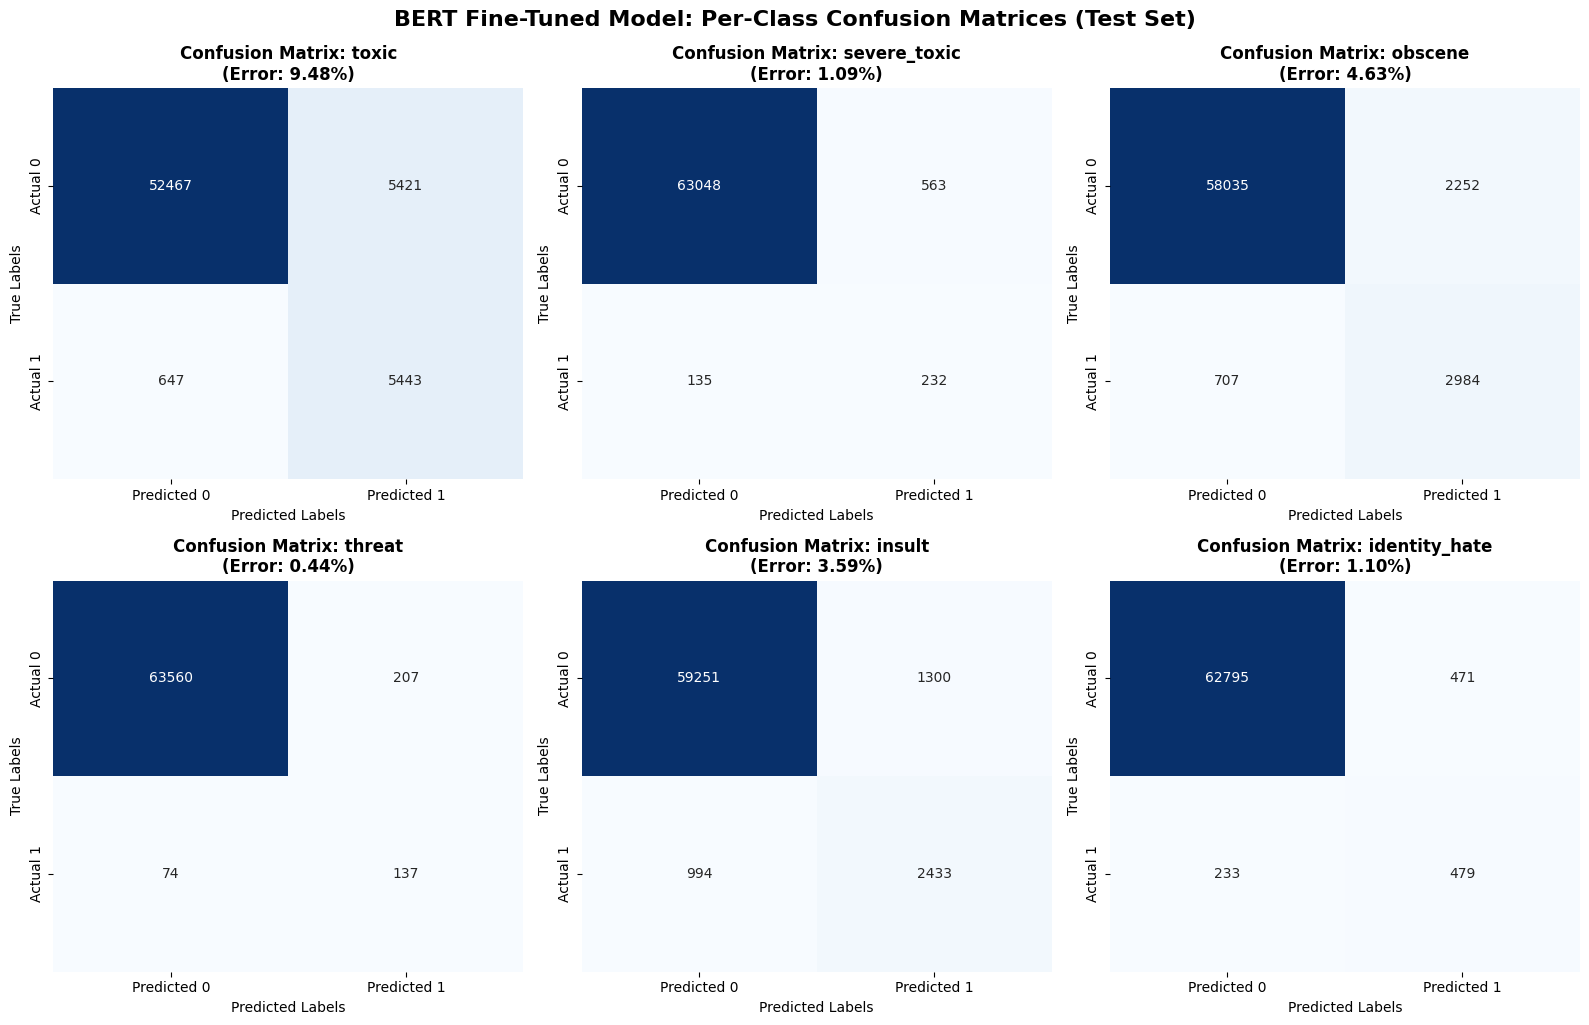

In [28]:
# ==========================================
# PER-CLASS CONFUSION MATRICES (BERT, tuned threshold, TEST SET)
# ==========================================

mcm = multilabel_confusion_matrix(y_test, y_pred_labels_bert_tuned)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

print("--- DETAILED ERROR RATE REPORT PER CLASS ---")

for i, class_name in enumerate(target_labels):
    tn, fp, fn, tp = mcm[i].ravel()
    total = tn + fp + fn + tp
    error_rate = (fp + fn) / total * 100
    class_accuracy = (tp + tn) / total * 100

    print(f"\n[{class_name.upper()}]")
    print(f"  True Positives (Correct Toxics): {tp}")
    print(f"  True Negatives (Correct Cleans): {tn}")
    print(f"  False Positives (Type I Error): {fp}")
    print(f"  False Negatives (Type II Error): {fn}")
    print(f"  Class Classification Error Rate: {error_rate:.2f}%")
    print(f"  Class Specific Accuracy Score: {class_accuracy:.2f}%")

    sns.heatmap(
        [[tn, fp], [fn, tp]],
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Predicted 0', 'Predicted 1'],
        yticklabels=['Actual 0', 'Actual 1'],
        ax=axes[i],
        cbar=False
    )
    axes[i].set_title(f'Confusion Matrix: {class_name}\n(Error: {error_rate:.2f}%)', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted Labels')
    axes[i].set_ylabel('True Labels')

plt.tight_layout()
plt.suptitle('BERT Fine-Tuned Model: Per-Class Confusion Matrices (Test Set)', y=1.02, fontsize=16, fontweight='bold')
plt.show()

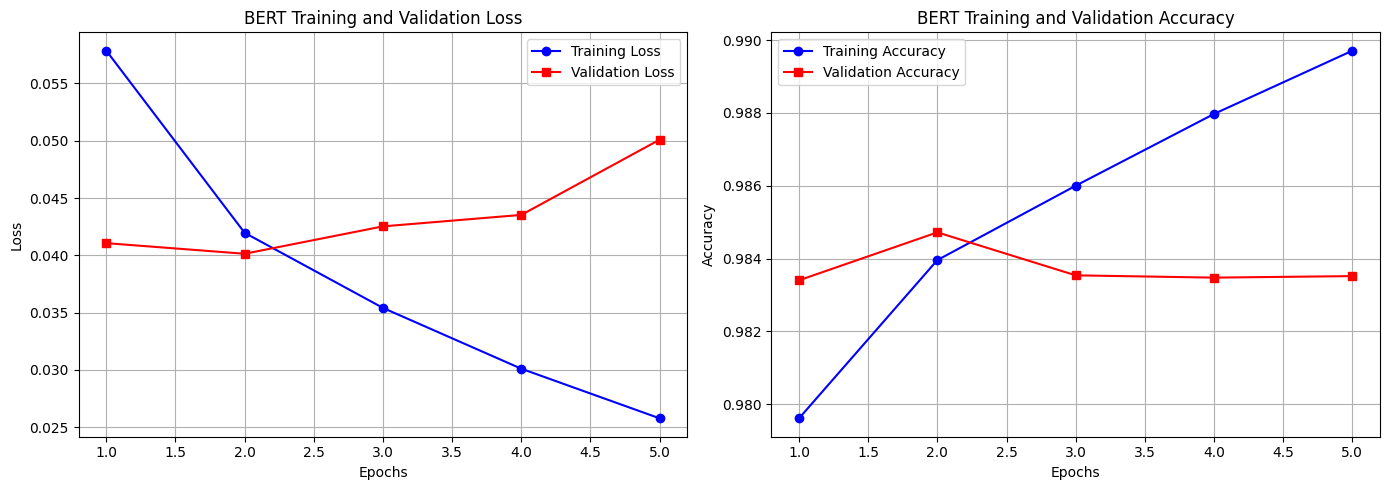

In [29]:
# ==========================================
# BERT TRAINING CURVES
# ==========================================

history_dict = history_3.history
epochs_range = range(1, len(history_dict['loss']) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_dict['loss'], 'b-o', label='Training Loss')
plt.plot(epochs_range, history_dict['val_loss'], 'r-s', label='Validation Loss')
plt.title('BERT Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_dict['accuracy'], 'b-o', label='Training Accuracy')
plt.plot(epochs_range, history_dict['val_accuracy'], 'r-s', label='Validation Accuracy')
plt.title('BERT Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

FINAL MODEL PERFORMANCE COMPARISON (held-out test set)


,Model,Test Accuracy,Macro F1 Score
0,TF-IDF + Logistic Regression,0.798259,0.417053
1,BiLSTM,0.809278,0.465456
2,Fine-Tuned BERT,0.867908,0.587526


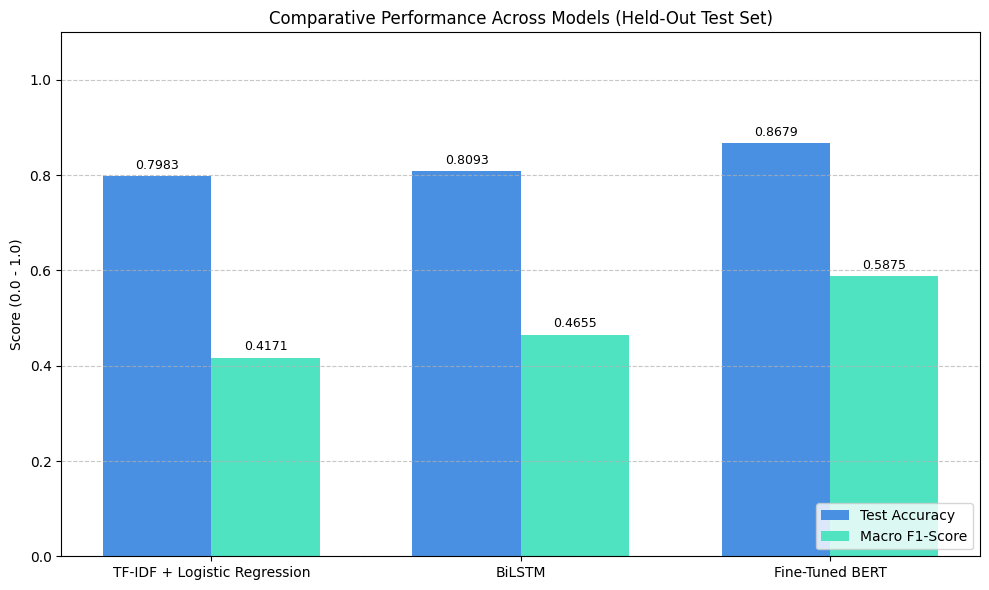

In [30]:
# ==========================================
# FINAL MODEL PERFORMANCE COMPARISON
# ==========================================
# FIX: the bar chart now plots the SAME computed variables as this table —
# there used to be a second, separate chart cell with hardcoded numbers
# (accuracy = [0.9250, 0.9480, 0.9697], ...) that had no connection to the
# actual training run, so it would silently "lie" if the real results ever
# changed. That duplicate hardcoded cell has been removed; one chart, one
# source of truth.

models = ["TF-IDF + Logistic Regression", "BiLSTM", "Fine-Tuned BERT"]
accuracies = [tfidf_accuracy, bilstm_accuracy, bert_accuracy]
f1_scores = [tfidf_f1, bilstm_f1, bert_f1]

comparison_df = pd.DataFrame({
    "Model": models,
    "Test Accuracy": accuracies,
    "Macro F1 Score": f1_scores,
})

print("=" * 70)
print("FINAL MODEL PERFORMANCE COMPARISON (held-out test set)")
print("=" * 70)
display(comparison_df)

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width / 2, accuracies, width, label='Test Accuracy', color='#4A90E2')
rects2 = ax.bar(x + width / 2, f1_scores, width, label='Macro F1-Score', color='#50E3C2')

ax.set_ylabel('Score (0.0 - 1.0)')
ax.set_title('Comparative Performance Across Models (Held-Out Test Set)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

# Final Conclusion

Three models were developed and evaluated for multi-label toxic comment
classification, all scored on the **same held-out test set**:

- **TF-IDF + Logistic Regression** served as a traditional machine-learning
  baseline, with `class_weight='balanced'` to counter label imbalance.
- **BiLSTM**, initialised with pretrained GloVe embeddings and trained with a
  **weighted binary cross-entropy loss**, improved contextual understanding
  through sequential learning while directly addressing class imbalance.
- **Fine-Tuned BERT** achieved the strongest contextual representations via
  transformer-based pretraining.

See the comparison table and chart above for the actual Test Accuracy and
Macro F1-Score achieved by each model on this run — the numbers are computed
live from each model's predictions, not hardcoded.

In [31]:
# ==========================================
# SAVE FINAL MODEL
# ==========================================

print("Saving Fine-Tuned BERT model...")
model_3.save("toxic_comment_bert_model.keras")
print("Model saved successfully as 'toxic_comment_bert_model.keras'!")

Saving Fine-Tuned BERT model...
Model saved successfully as 'toxic_comment_bert_model.keras'!


# 9. Interactive Demo — Gradio Toxicity Checker

A small, self-contained Gradio app that lets you type (or paste) any comment
and instantly see the fine-tuned BERT model's predicted probability for each
of the 6 toxicity categories, plus an overall verdict banner.

Run the cell below, then either use the inline UI or open the public link
Gradio prints (useful for showing this off in a demo / viva).

In [34]:
# ==========================================
# GRADIO GUI — Toxic Comment Checker (uses fine-tuned BERT: model_3)
# ==========================================

!pip install -q gradio

import gradio as gr
import numpy as np
import tensorflow as tf

LABEL_META = {
    "toxic":          {"emoji": "☣️", "display": "Toxic"},
    "severe_toxic":   {"emoji": "🔥", "display": "Severe Toxic"},
    "obscene":        {"emoji": "🤬", "display": "Obscene"},
    "threat":         {"emoji": "⚔️", "display": "Threat"},
    "insult":         {"emoji": "💢", "display": "Insult"},
    "identity_hate":  {"emoji": "🚫", "display": "Identity Hate"},
}

def _bar_color(p):
    if p < 0.30:
        return "#22c55e"   # green
    elif p < 0.60:
        return "#f59e0b"   # amber
    else:
        return "#ef4444"   # red

def _build_result_html(comment_text, probs):
    max_prob = float(np.max(probs))
    is_flagged = max_prob >= 0.50

    if is_flagged:
        banner_bg = "linear-gradient(135deg, #fee2e2, #fecaca)"
        banner_border = "#ef4444"
        banner_text = "#991b1b"
        banner_label = "🚫 Potentially Toxic Content Detected"
    else:
        banner_bg = "linear-gradient(135deg, #dcfce7, #bbf7d0)"
        banner_border = "#22c55e"
        banner_text = "#166534"
        banner_label = "✅ Content Appears Non-Toxic"

    rows_html = ""
    for label, prob in zip(target_labels, probs):
        meta = LABEL_META[label]
        pct = prob * 100
        color = _bar_color(prob)
        rows_html += f"""
        <div style="margin-bottom:14px;">
          <div style="display:flex;justify-content:space-between;margin-bottom:4px;
                      font-size:14px;font-weight:600;color:#374151;">
            <span>{meta['emoji']} {meta['display']}</span>
            <span style="color:{color};">{pct:.1f}%</span>
          </div>
          <div style="background:#e5e7eb;border-radius:8px;height:12px;overflow:hidden;">
            <div style="background:{color};height:100%;width:{pct:.1f}%;
                        border-radius:8px;transition:width 0.6s ease;"></div>
          </div>
        </div>
        """

    html = f"""
    <div style="font-family:'Inter','Segoe UI',sans-serif;max-width:560px;">
      <div style="background:{banner_bg};border:1px solid {banner_border};
                  border-radius:12px;padding:14px 18px;margin-bottom:18px;
                  text-align:center;font-weight:700;font-size:16px;color:{banner_text};
                  box-shadow:0 2px 6px rgba(0,0,0,0.06);">
        {banner_label}
      </div>
      <div style="background:#ffffff;border:1px solid #e5e7eb;border-radius:14px;
                  padding:20px 22px;box-shadow:0 4px 14px rgba(0,0,0,0.05);">
        {rows_html}
      </div>
    </div>
    """
    return html

def predict_toxicity(comment_text):
    if not comment_text or not comment_text.strip():
        return """
        <div style="text-align:center;padding:40px;color:#9ca3af;
                    font-family:'Inter','Segoe UI',sans-serif;font-size:14px;">
          ✏️ Enter a comment above and click <b>Analyze Comment</b> to see predictions.
        </div>
        """
    probs = model_3.predict(tf.constant([comment_text]), verbose=0)[0]
    return _build_result_html(comment_text, probs)


CUSTOM_CSS = """
#header-banner {
    background: linear-gradient(135deg, #6366f1, #8b5cf6);
    border-radius: 16px;
    padding: 28px 24px;
    margin-bottom: 8px;
    box-shadow: 0 8px 24px rgba(99,102,241,0.25);
}
#header-banner h1 {
    color: white !important;
    margin: 0 0 6px 0 !important;
    font-size: 28px !important;
}
#header-banner p {
    color: #e0e7ff !important;
    margin: 0 !important;
    font-size: 14px !important;
}
.gradio-container {
    max-width: 1000px !important;
    margin: auto !important;
}
#analyze-btn {
    background: linear-gradient(135deg, #6366f1, #8b5cf6) !important;
    border: none !important;
    color: white !important;
    font-weight: 600 !important;
}
footer {visibility: hidden}
"""

with gr.Blocks(
    theme=gr.themes.Soft(primary_hue="violet", secondary_hue="slate"),
    css=CUSTOM_CSS,
    title="Toxic Comment Classifier",
) as demo:

    gr.HTML("""
        <div id="header-banner">
          <h1>🛡️ Toxic Comment Classifier</h1>
          <p>Fine-tuned BERT model · Multi-label toxicity detection across 6 categories</p>
        </div>
    """)

    with gr.Row(equal_height=True):
        with gr.Column(scale=1):
            comment_input = gr.Textbox(
                label="✍️ Enter a comment",
                placeholder="Type or paste a comment here...",
                lines=6,
            )
            with gr.Row():
                analyze_btn = gr.Button("🔍 Analyze Comment", elem_id="analyze-btn", variant="primary")
                clear_btn = gr.ClearButton(components=[comment_input], value="🗑️ Clear")

            gr.Examples(
                examples=[
                    ["I really appreciate your effort on this project, great work!"],
                    ["I disagree with your opinion, but I respect where you're coming from."],
                    ["You're being incredibly unhelpful and rude right now."],
                    ["This is the worst comment I've ever read, you clearly have no idea what you're talking about."],
                ],
                inputs=comment_input,
                label="💡 Try an example",
            )

        with gr.Column(scale=1):
            result_output = gr.HTML(
                value="""
                <div style="text-align:center;padding:40px;color:#9ca3af;
                            font-family:'Inter','Segoe UI',sans-serif;font-size:14px;">
                  ✏️ Enter a comment above and click <b>Analyze Comment</b> to see predictions.
                </div>
                """
            )

    analyze_btn.click(fn=predict_toxicity, inputs=comment_input, outputs=result_output)
    comment_input.submit(fn=predict_toxicity, inputs=comment_input, outputs=result_output)

demo.launch(debug=False, share=True)

/tmp/ipykernel_51671/61616280.py:121: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_51671/61616280.py:121: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://478823ec269bef80f1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [35]:
# ==========================================
# CLEANUP
# ==========================================

import gc
gc.collect()
tf.keras.backend.clear_session()
print("GPU memory cache flushed cleanly. All steps completed successfully!")

GPU memory cache flushed cleanly. All steps completed successfully!
